# AIM 1

In [23]:
import pybedtools
from pybedtools import BedTool
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import *
from scipy.stats import fisher_exact
from scipy.stats.contingency import odds_ratio
import os


load files

In [24]:
genome = 'GRCh38_EBV.chrom.sizes.tsv'

hot_loci_name = 'hot_regions.clean.bed'
h3k4me3_name = 'K562_H3K4me3.bed'
h3k27ac_name = 'K562_H3K27ac.bed'
h3k27me3_name = 'K562_H3k27me3.bed'
h3k9me3_name = 'K562_H3K9me3.bed'

hot = BedTool(hot_loci_name).sort(g=genome)
marks = {
    'H3K4me3': BedTool(h3k4me3_name).sort(g=genome), # active
    'H3K27ac': BedTool(h3k27ac_name).sort(g=genome), # active
    'H3K27me3': BedTool(h3k27me3_name).sort(g=genome), # repressive
    'H3K9me3': BedTool(h3k9me3_name).sort(g=genome) # repressive
}

n_hot = hot.count()

print(n_hot, 'hot regions')
for name, bt in marks.items():
    print(bt.count(), name, 'peaks')



5990 hot regions
21445 H3K4me3 peaks
52334 H3K27ac peaks
163784 H3K27me3 peaks
5584 H3K9me3 peaks


find regions on the genome, filtered using blacklist regions

separately, find bivalent regions which have active and repressive marks

In [25]:
blacklist = BedTool('hg38-blacklist.v2.bed.gz').sort(g=genome)
blacklist_stable = blacklist.saveas('blacklist.sorted.bed')

clean = BedTool('merged_tf_counts.bed').sort(g=genome).intersect(blacklist, v=True)
n_clean = clean.count()
print(f"{n_clean} 'clean' loci (regions on the genome which exhibit *some* tf binding)")

hot = clean.intersect(hot, u=True) # clean loci overlapping hot
not_hot = clean.intersect(hot, v=True) # clean loci not overlapping hot

print(hot.count(), 'hot')
print(not_hot.count(), 'not hot')
print(hot.count()+not_hot.count(), 'sum of hot and not hot (should be equal to clean loci)')

both_marks = marks['H3K4me3'].intersect(marks['H3K27me3']).sort(g=genome).merge()
marks = {**marks, 'bivalent': both_marks}

594202 'clean' loci (regions on the genome which exhibit *some* tf binding)
5990 hot
588212 not hot
594202 sum of hot and not hot (should be equal to clean loci)


enrichment of each mark at hot loci, odds ratio forest plot

In [26]:
marks_odds = []
for mark_name, mark_bed in marks.items():
    
    both = hot.intersect(mark_bed, u=True).count()
    hot_only = hot.intersect(mark_bed, v=True).count()
    mark_only = not_hot.intersect(mark_bed, u=True).count()
    neither = not_hot.intersect(mark_bed, v=True).count()

    odds = (neither * both) / (hot_only * mark_only)
    se = np.sqrt(1/neither + 1/hot_only + 1/mark_only + 1/both)
    z = 1.96
    lower, upper = np.exp(np.log(odds) - z * se), np.exp(np.log(odds) + z * se)

    marks_odds.append(
        {
            'mark': mark_name,
            'odds': odds, 
            'lower': lower,
            'upper': upper
        }
    )

pp(marks_odds)


[{'mark': 'H3K4me3',
  'odds': 7.2852072404240555,
  'lower': np.float64(6.763883958405969),
  'upper': np.float64(7.846711277470674)},
 {'mark': 'H3K27ac',
  'odds': 626.3800709458991,
  'lower': np.float64(543.1701587347949),
  'upper': np.float64(722.337166298116)},
 {'mark': 'H3K27me3',
  'odds': 0.14587397380186656,
  'lower': np.float64(0.12155152102581152),
  'upper': np.float64(0.1750633480615105)},
 {'mark': 'H3K9me3',
  'odds': 7.478011467644669,
  'lower': np.float64(6.486755335124054),
  'upper': np.float64(8.620743749564545)},
 {'mark': 'bivalent',
  'odds': 0.4489263071180422,
  'lower': np.float64(0.2135600130433611),
  'upper': np.float64(0.9436917817649845)}]


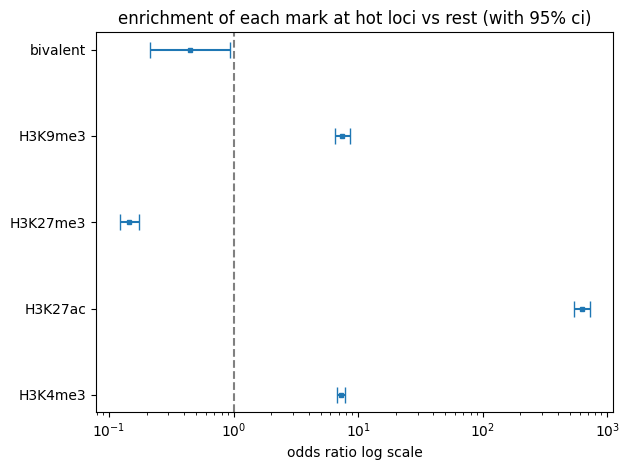

In [61]:
marks_odds = pd.DataFrame(marks_odds)

y_positions = np.arange(len(marks_odds))

plt.figure()

xerr = [
    marks_odds['odds'] - marks_odds['lower'],
    marks_odds['upper'] - marks_odds['odds']
]

plt.errorbar(
    marks_odds['odds'],
    y_positions,
    xerr = xerr,
    fmt = 's',
    ms = 3,
    capsize = 6
)
plt.yticks(y_positions, marks_odds['mark'])
plt.axvline(1, color='grey', linestyle='--')
plt.xscale('log')
plt.xlabel('odds ratio log scale')
plt.title('enrichment of each mark at hot loci vs rest (with 95% ci)')
plt.tight_layout()
plt.savefig('plot_mark_enrichment')
plt.show()

percentile binned design

In [28]:
bin_edges = (0,50,80,90,95,99,100)
quantiles = [i/100 for i in bin_edges]

df_clean = clean.to_dataframe(names=['chrom', 'start', 'end', 'tfs', 'n_tfs'])
bin_edge_values = df_clean['n_tfs'].quantile(quantiles).values

label_text = [f'{bin_edges[i]}-{bin_edges[i+1]}' for i in range(len(bin_edges) - 1)]

df_clean['occupancy_bin'] = pd.cut(
    df_clean['n_tfs'],
    bins = bin_edge_values,
    labels = label_text,
    include_lowest = True,
    duplicates = 'drop'
)

df_clean['occupancy_bin'].value_counts().sort_index()



occupancy_bin
0-50      375483
50-80     112304
80-90      48007
90-95      28740
95-99      23752
99-100      5916
Name: count, dtype: int64

overlap % by occupancy bin, per mark

In [29]:
binned_clean = BedTool.from_dataframe(
    df_clean[['chrom', 'start', 'end', 'occupancy_bin']].astype({'occupancy_bin': str})
).sort(g = genome)

data = []
for mark, mark_bed in marks.items():

    hits = binned_clean.intersect(mark_bed, c = True)
    hits_df = hits.to_dataframe(
        names=['chrom', 'start', 'end', 'occupancy_bin', 'overlap_count']
    )
    hits_df['has_overlap'] = hits_df['overlap_count'] > 0

    bin_percentages = hits_df.groupby("occupancy_bin", observed=True)["has_overlap"].mean() * 100

    for bin, pct in bin_percentages.items():
        data.append(
            {
                "mark": mark,
                "occupancy_bin": bin,
                "pct_overlap": pct
            }
        )

print(pd.DataFrame(data))

        mark occupancy_bin  pct_overlap
0    H3K4me3          0-50     1.798750
1    H3K4me3         50-80     2.223429
2    H3K4me3         80-90     2.810007
3    H3K4me3         90-95     3.535143
4    H3K4me3         95-99     6.824688
5    H3K4me3        99-100    14.435429
6    H3K27ac          0-50     0.559546
7    H3K27ac         50-80     1.530667
8    H3K27ac         80-90     4.972192
9    H3K27ac         90-95    17.226862
10   H3K27ac         95-99    64.373526
11   H3K27ac        99-100    96.703854
12  H3K27me3          0-50    11.328609
13  H3K27me3         50-80    14.037790
14  H3K27me3         80-90    15.245693
15  H3K27me3         90-95    13.378566
16  H3K27me3         95-99     7.393062
17  H3K27me3        99-100     1.960784
18   H3K9me3          0-50     0.179502
19   H3K9me3         50-80     0.601047
20   H3K9me3         80-90     1.460204
21   H3K9me3         90-95     1.419624
22   H3K9me3         95-99     1.684069
23   H3K9me3        99-100     3.566599


for each bin and histone modification, plotted is the fraction of loci in that bin which have atleast one peak of that mark (binary yes/no)

shows if a marks association changes according to tf occupancy

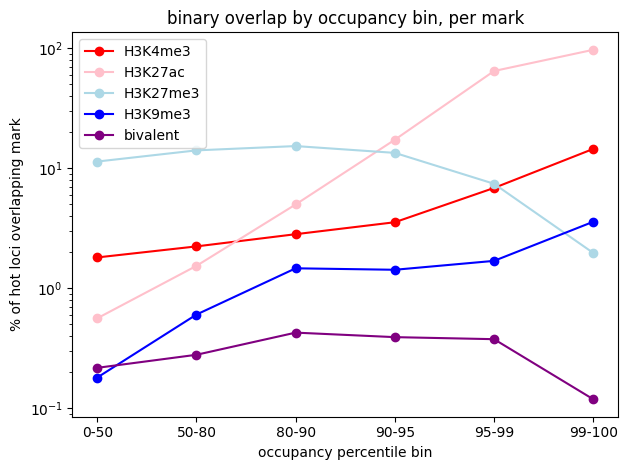

In [30]:
bins_df = pd.DataFrame(data)

bin_order = list(df_clean['occupancy_bin'].cat.categories)

colour_map = {
    "H3K4me3": "red",  # active
    "H3K27ac": "pink",  # active
    "H3K27me3": "lightblue",  # repressive
    "H3K9me3": "blue",  # repressive
    "bivalent": "purple",  # both
}

plt.figure()
for mark_name in marks:
    sub = bins_df[bins_df['mark'] == mark_name].set_index('occupancy_bin').reindex(bin_order)
    plt.plot(bin_order, sub['pct_overlap'], marker='o', label=mark_name, color = colour_map[mark_name])

plt.xlabel('occupancy percentile bin')
plt.ylabel('% of hot loci overlapping mark')
plt.title('binary overlap by occupancy bin, per mark')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('plot_overlap_by_bin.png', dpi=300)
plt.show()

formalise the odds ratios found above for hot loci (99th percentile bins) by permutation based significance testing against a shuffled null

this block generates odds ratios by shuffling mark bed files an n_perms number of times then calculates odds ratios in the same way as above

In [ ]:
# 100 iterations are about 6.5 minutes

# fast odds calculation code by claude
n_hot = hot.count()
n_not_hot = not_hot.count()

blacklist_stable = blacklist.saveas('blacklist.sorted.bed')

hot_tagged = hot.each(
    lambda f: pybedtools.create_interval_from_list(list(f)[:3] + ['1'])
).saveas()
not_hot_tagged = not_hot.each(
    lambda f: pybedtools.create_interval_from_list(list(f)[:3] + ['0'])
).saveas()

clean_labeled = BedTool.cat(hot_tagged, not_hot_tagged, postmerge=False) \
    .sort(g=genome) \
    .saveas('clean_labeled.bed')


def odds(mark_bed):
    hits = clean_labeled.intersect(mark_bed, c=True)  # one bedtools call
    df = hits.to_dataframe(names=['chrom', 'start', 'end', 'is_hot', 'overlap_count'])

    # is_hot comes back as int64 (values are digit-only), not string — compare as int
    both = ((df['is_hot'] == 1) & (df['overlap_count'] > 0)).sum()
    mark_only = ((df['is_hot'] == 0) & (df['overlap_count'] > 0)).sum()
    hot_only = n_hot - both
    neither = n_not_hot - mark_only

    if 0 in (both, hot_only, mark_only, neither):
        both, hot_only, mark_only, neither = both + 0.5, hot_only + 0.5, mark_only + 0.5, neither + 0.5

    out = (neither * both) / (hot_only * mark_only)
    return out.item()


odds_null = {}

for mark_name, mark_bed in marks.items():
    
    if mark_name == 'bivalent':
        odds_null['bivalent'] = []
        for i in range(n_perms):
            shuffled_k4 = marks['H3K4me3'].shuffle(g=genome, excl=blacklist_stable.fn, chrom=True).saveas()
            shuffled_k27 = marks['H3K27me3'].shuffle(g=genome, excl=blacklist_stable.fn, chrom=True).saveas()
            shuffled_bivalent = shuffled_k27.intersect(shuffled_k4).sort(g = genome).merge().saveas()
            odds_null['bivalent'].append(odds(shuffled_bivalent))
            os.remove(shuffled_k4.fn)
            os.remove(shuffled_k27.fn)
            os.remove(shuffled_bivalent.fn)  
        continue

    odds_null[mark_name] = []

    for i in range(n_perms):
        shuffled = mark_bed.shuffle(g = genome,excl = blacklist_stable.fn,chrom = True).saveas()
        odds_null[mark_name].append(odds(shuffled))
        os.remove(shuffled.fn) 

print(odds_null)

{'H3K4me3': [3.4703714710576214, 3.77355118064765, 3.3520468450435645, 3.8685114238633815, 3.380915016055373, 3.5236317135203232, 3.566095509461849, 3.715649323696225, 3.440134745213339, 3.482366347495826, 3.404420398701634, 3.498176003535113, 3.72823877307359, 3.636112091534956, 3.559530411790494, 3.6687987881861917, 3.4877384749215063, 3.5305736830796404, 3.584788223728968, 3.487866551623399, 3.553820843592083, 3.3332491730317138, 3.334269941435362, 3.412088931965402, 3.41285204591579, 3.418688939515307, 3.521672536450825, 3.6452832479255397, 3.6543759395019917, 3.4523190495205074, 3.2635590209339327, 3.2081817206872008, 3.6536912260833803, 3.6010026775793063, 3.896352087500373, 3.7604553521610193, 3.55102861678985, 3.093398901849813, 3.5102970117322694, 3.469667446596368, 3.575008707898043, 3.8608658357512406, 3.6562935426031795, 3.361338010496084, 3.3046614904380722, 3.4494951398931746, 3.509435962795787, 3.713755841182359, 3.8237939071291343, 3.743417437212303, 3.653991653953722, 

In [63]:
pp(odds_null)

{'H3K4me3': [3.4703714710576214,
             3.77355118064765,
             3.3520468450435645,
             3.8685114238633815,
             3.380915016055373,
             3.5236317135203232,
             3.566095509461849,
             3.715649323696225,
             3.440134745213339,
             3.482366347495826,
             3.404420398701634,
             3.498176003535113,
             3.72823877307359,
             3.636112091534956,
             3.559530411790494,
             3.6687987881861917,
             3.4877384749215063,
             3.5305736830796404,
             3.584788223728968,
             3.487866551623399,
             3.553820843592083,
             3.3332491730317138,
             3.334269941435362,
             3.412088931965402,
             3.41285204591579,
             3.418688939515307,
             3.521672536450825,
             3.6452832479255397,
             3.6543759395019917,
             3.4523190495205074,
             3.2635590209339327,

proceed by calculating p values

fraction of odds ratios under the null which are as extreme as observed odds ratios

correct for false discovery rate for multiple testing

In [58]:
from statsmodels.stats.multitest import multipletests
results = []
for mark_name, observed_odds in zip(marks_odds['mark'],marks_odds['odds']):
    
    odds_array = np.array(odds_null[mark_name])

    if observed_odds >= 1:
        p = (np.sum(odds_array >= observed_odds)+ 1) / (len(odds_array) + 1)
    else:
        p = (np.sum(odds_array <= observed_odds)+ 1) / (len(odds_array) + 1)

    results.append(
        {
            'mark':         mark_name,
            'observed_or':  observed_odds,
            'null_median':  np.median(odds_array),
            'null_p2.5':    np.percentile(odds_array, 2.5),
            'null_p97.5':   np.percentile(odds_array, 97.5),
            'p_value':      p
        }
    )

results = pd.DataFrame(results)
results['p_adjusted'] = multipletests(results['p_value'], method='fdr_bh')[1]

pp(results)

       mark  observed_or  null_median  null_p2.5  null_p97.5   p_value  \
0   H3K4me3     7.285207     3.514526   3.158205    3.883128  0.009901   
1   H3K27ac   626.380071     4.493420   4.216446    4.919899  0.009901   
2  H3K27me3     0.145874     4.377091   4.129191    4.580244  0.009901   
3   H3K9me3     7.478011     6.844904   5.113546    8.573378  0.237624   
4  bivalent     0.448926     5.459054   3.908066    7.073858  0.009901   

   p_adjusted  
0    0.012376  
1    0.012376  
2    0.012376  
3    0.237624  
4    0.012376  


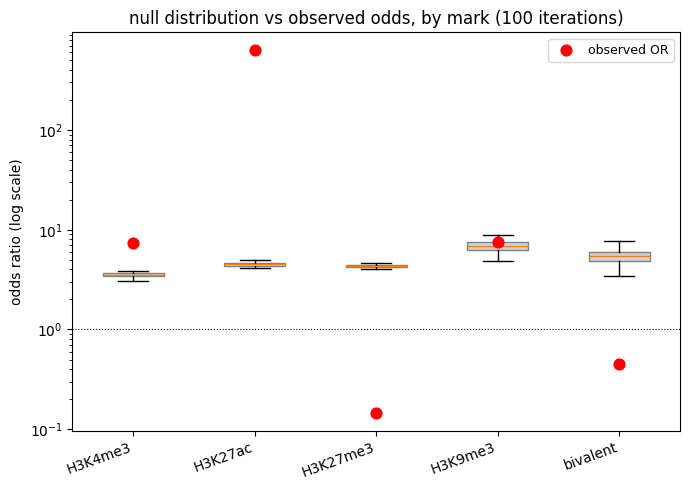

In [60]:
fig, ax = plt.subplots(figsize=(7, 5))

mark_names = list(odds_null.keys())
null_data = [np.array(odds_null[m]) for m in mark_names]

bp = ax.boxplot(null_data, tick_labels=mark_names, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set(facecolor='lightgrey', edgecolor='grey')

# overlay each mark's observed OR as a single red point, at that mark's x position
for i, mark_name in enumerate(mark_names):
    observed_or = marks_odds.set_index('mark').loc[mark_name, 'odds']
    ax.scatter(i + 1, observed_or, color='red', zorder=3, s=60,
               label='observed OR' if i == 0 else None)

ax.set_yscale('log')
ax.set_ylabel('odds ratio (log scale)')

ax.set_title(f"null distribution vs observed odds, by mark ({len(odds_null['bivalent'])} iterations)")
ax.axhline(1, color='black', linestyle=':', linewidth=0.8)
ax.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('plot_permutation_boxplot.png', dpi=300)
plt.show()

In [ ]:
# pybedtools.cleanup(remove_all=True, verbose=True)

removing /var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/pybedtools.jkbfa0z3.tmp
removing /var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/pybedtools.ju0klhpb.tmp
removing /var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/pybedtools.zrzi32vu.tmp
removing /var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/pybedtools.kp1oaoo9.tmp
removing /var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/pybedtools.ourm8ghj.tmp
removing /var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/pybedtools.x928qtj_.tmp
removing /var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/pybedtools.p4ldxu3u.tmp
removing /var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/pybedtools.ext47sbw.tmp
removing /var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/pybedtools.csoz89xf.tmp
removing /var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/pybedtools.wxncmw4n.tmp
removing /var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/pybedtools.239s8dqn.tmp
removing /var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/pybedtools.rspoudve.tmp
removing /var/fo

In [50]:
print(len(odds_null['bivalent']))

5
